Libraries

In [10]:
import os
import sys
from pathlib import Path
import re
from typing import List, Optional, Dict

# Automatically locate and add the 'src' folder to sys.path
project_root = Path(os.path.abspath(''))
src_path = project_root / "src"
if src_path not in sys.path:
    sys.path.insert(0, str(src_path))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, probplot

from imaging import io

import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
# warnings.filterwarnings('ignore')

Data Loading

In [ ]:
db_base_path = Path('/home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/DB/')

db_clinical                   = pd.read_excel(db_base_path / 'PESABrain_Clinical_20260216.xlsx')
db_clinical_all               = pd.read_excel(db_base_path / 'PESABrain_Clinical_AllXNAT_20260216.xlsx')
db_subject_catalog_all        = pd.read_excel(db_base_path / 'PESABrain_SubjectCatalog_AllXNAT_20260216.xlsx')
db_all_ids                    = pd.read_excel(db_base_path / 'PESABrain_All_IDs.xlsx')
db_all_4dflow_ids             = pd.read_excel(db_base_path / 'PESABrain_All_4DFlow_IDs.xlsx')
      
db_hemo                       = pd.read_excel(db_base_path / 'PESABrain_LocHemodynamic_20260406.xlsx')
db_4dflow_loc_tavg_flow       = pd.read_excel(db_base_path / 'PESABrain_4DFlow_LocalizedTimeAvgFlow_20260216.xlsx')
db_4dflow_loc_pi              = pd.read_excel(db_base_path / 'PESABrain_4DFlow_LocalizedPI_20260216.xlsx')
db_4dflow_loc_tseries         = pd.read_excel(db_base_path / 'PESABrain_4DFlow_LocalizedTimeseriesFlow_Wide_20260216.xlsx')

db_asl_desikan_avg_perfusion  = pd.read_excel(db_base_path / 'PESABrain_ASLPerfusion_ThrMeanCBF_20260216.xlsx')
db_asl_vascular_avg_perfusion = pd.read_excel(db_base_path / 'PESABrain_ASLPerfusion_VascularAtlas_MeanCBF_20260216.xlsx')

db_echo_carotide_plaque_vol   = pd.read_excel(db_base_path / 'PESABrain_Echography_CarotidePlaque_20260216.xlsx')
db_tac                        = pd.read_excel(db_base_path / 'PESABrain_TAC_20260318.xlsx')
db_apoe                       = pd.read_excel(db_base_path / 'PESABrain_APOE_20260318.xlsx')


subjects_all = db_all_ids.patient_id.unique()
subjects_4dflow_all = db_all_4dflow_ids.patient_id.unique()
subjects_4dflow_available = db_4dflow_loc_tavg_flow.patient_id.unique()

print(f'Total subjects: {len(subjects_all)}')
print(f'Total 4DFlow subjects: {len(subjects_4dflow_all)}')
print(f'Total 4DFlow available subjects: {len(subjects_4dflow_available)}')

Total subjects: 1001
Total 4DFlow subjects: 554
Total 4DFlow available subjects: 356


In [64]:
# atlas_base_path = db_base_path / 'ATLAS'

# asl_vascular_atlas, _        = io.imread(atlas_base_path / 'ctx_arterial_atlas_watershed.nii.gz')
# asl_vascular_atlas_filled, _ = io.imread(atlas_base_path / 'ctx_arterial_atlas_watershed.nii.gz')

Rest 4DFlow Metrics

In [20]:
db_4dflow_loc_tseries

,patient_id,vessel,vessel_code,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,PESA1006009,Basilar,BASI,171.740742,168.193645,152.294641,138.217177,136.751847,130.361080,120.433002,160.840273,252.938347,266.397772,262.681961,237.725158,188.848443,191.011362,189.220390
1,PESA1006009,Left ACA,LACA,130.583167,120.806365,100.575814,100.947096,102.167130,91.200171,91.744215,96.976891,150.563221,169.693065,166.880980,158.196101,130.403194,124.440322,123.174362
2,PESA1006009,Left ICA,LICA,252.617741,227.585850,217.659688,215.417776,201.988692,193.813677,186.178293,225.327344,367.114534,373.405952,368.191252,343.306303,284.935713,283.840456,264.153757
3,PESA1006009,Left MCA,LMCA,182.312708,172.590337,157.889471,149.896889,134.359145,124.708729,126.308742,143.241320,246.581469,253.717346,256.524439,242.574377,197.375464,195.805535,177.284031
4,PESA1006009,Left PCA,LPCA,79.050901,74.644411,72.189739,70.600963,64.648776,61.915970,52.655289,63.982408,113.264236,121.442585,123.644414,109.093215,97.553937,80.561221,97.342601
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4792,PESA9972964,Right PCA,RPCA,131.166244,138.457603,115.512207,112.447944,109.679568,90.826857,85.164557,75.004628,84.418058,103.258145,157.761583,149.847407,153.542705,138.528886,132.937260
4793,PESA9972964,Right Transverse,RTSV,109.943755,112.859838,99.204690,93.532991,83.936920,81.508119,85.035467,73.821259,67.044060,79.758067,100.106213,116.136246,118.236308,108.490698,99.025147
4794,PESA9972964,Sagital Sinus,SSSV,365.355949,361.253529,353.166418,334.831867,310.467510,293.542356,281.895618,275.544004,268.131552,291.948709,356.593580,396.678743,418.609200,392.719746,374.781504
4795,PESA9972964,Straight Sinus,STRV,62.573998,69.366059,78.029680,67.068143,61.704111,63.942418,64.835122,54.955616,59.211398,64.498208,64.958110,78.313208,80.731587,76.291730,71.346781


In [22]:
VESSEL_ALIASES = {
  "LICA": {"lica", "leftica", "lefticacavernous", "lefticacervical", "lcav", "lcer"},
  "RICA": {"rica", "rightica", "righticacavernous", "righticacervical", "rcav", "rcer"},
  "BASI": {"basi", "ba", "basilar"},
  "LMCA": {"lmca", "leftmca"},
  "RMCA": {"rmca", "rightmca"},
  "LACA": {"laca", "leftaca"},
  "RACA": {"raca", "rightaca"},
  "LPCA": {"lpca", "leftpca"},
  "RPCA": {"rpca", "rightpca"},
  "SSSV": {"sssv", "sss", "sagsinus", "sagitalsinus", "sagitalsinus", "sssinus", "sssv"},
  "STRV": {"strv", "straightsinus", "straightsinus", "ss"},
  "LTSV": {"ltsv", "ltrv", "lefttransverse", "lefttransversesinus"},
  "RTSV": {"rtsv", "rtrv", "righttransverse", "righttransversesinus"},
}

COMM_TOKENS = {
  "lcomm", "rcomm", "leftcommunicating", "rightcommunicating", "communicating"
}

ARTERIAL_CODES = ["LICA", "RICA", "BASI", "LMCA", "RMCA", "LACA", "RACA", "LPCA", "RPCA"]
VENOUS_CODES = ["SSSV", "STRV", "LTSV", "RTSV"]

# APCPI:
# anterior = ICA + ACA + MCA
# posterior = Basilar + PCA
APCPI_ANTERIOR_CODES = ["LICA", "RICA", "LACA", "RACA", "LMCA", "RMCA"]
APCPI_POSTERIOR_CODES = ["BASI", "LPCA", "RPCA"]

# IPB: Mean(ICAs, Basi)
IPB_CODES = ["LICA", "RICA", "BASI"]

def _norm(text: str) -> str:
  return re.sub(r"[^a-z0-9]+", "", str(text).strip().lower())

def _safe_mean(values: List[float]) -> float:
  vals = np.asarray([v for v in values if pd.notna(v)], dtype=float)
  return np.nan if len(vals) == 0 else float(np.nanmean(vals))
  
def _safe_ratio(num: float, den: float) -> float:
  if pd.isna(num) or pd.isna(den) or np.isclose(den, 0):
      return np.nan
  return float(num / den)
  
def _canonical_vessel_from_sheet(sheet_name: str) -> Optional[str]:
  prefix = re.sub(r"_T_(averaged|resolved)$", "", sheet_name, flags=re.IGNORECASE)
  prefix_n = _norm(prefix)
  if any(tok in prefix_n for tok in COMM_TOKENS):
      return None
  for canon, aliases in VESSEL_ALIASES.items():
      if prefix_n in aliases:
          return canon
  return None


def _standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
  col_map = {}
  for c in df.columns:
      cn = _norm(c)
      if cn == "pointalongvessel":
          col_map[c] = "point_along_vessel"
      elif cn == "areacm2":
          col_map[c] = "area_cm2"
      elif cn == "maxvelocitycms":
          col_map[c] = "max_velocity_cms"
      elif cn == "meanvelocitycms":
          col_map[c] = "mean_velocity_cms"
      elif cn == "averageflowmls":
          col_map[c] = "average_flow_mls"
      elif cn == "pulsatilityindex":
          col_map[c] = "pi"
      elif cn == "resistivityindex":
          col_map[c] = "ri"
  out = df.rename(columns=col_map).copy()
  return out


def _read_middle_loc_metrics(summary_xls: Path, sheet_name: str) -> Dict[str, float]:
  # For .xls, pandas typically needs xlrd installed.
  df = pd.read_excel(summary_xls, sheet_name=sheet_name, engine="xlrd")
  df = _standardize_columns(df)
  required = [
      "point_along_vessel",
      "area_cm2",
      "max_velocity_cms",
      "average_flow_mls",
      "pi",
      "ri",
  ]
  missing = [c for c in required if c not in df.columns]
  if missing:
      raise ValueError(f"{summary_xls.name} / {sheet_name}: missing columns {missing}")
  df["point_along_vessel"] = pd.to_numeric(df["point_along_vessel"], errors="coerce")
  numeric_rows = df[df["point_along_vessel"].notna()].copy()
  if numeric_rows.empty:
      raise ValueError(f"{summary_xls.name} / {sheet_name}: no numeric LOC rows found")
  numeric_rows = numeric_rows.sort_values("point_along_vessel").reset_index(drop=True)
  # Use the middle measurement among the 5 sampled centerline points
  mid_idx = len(numeric_rows) // 2
  row = numeric_rows.iloc[mid_idx]
  return {
      "loc_point": int(row["point_along_vessel"]),
      "flow": float(pd.to_numeric(row["average_flow_mls"], errors="coerce")),
      "area": float(pd.to_numeric(row["area_cm2"], errors="coerce")),
      "psv": float(pd.to_numeric(row["max_velocity_cms"], errors="coerce")),
      "pi": float(pd.to_numeric(row["pi"], errors="coerce")),
      "ri": float(pd.to_numeric(row["ri"], errors="coerce")),
  }

def _build_patient_record(patient_id: str, summary_xls: Path) -> Dict[str, float]:
  xls = pd.ExcelFile(summary_xls, engine="xlrd")
  averaged_sheets = [s for s in xls.sheet_names if s.lower().endswith("_t_averaged")]
  record: Dict[str, float] = {"patient_id": patient_id}
  seen_codes = set()
  for sheet_name in averaged_sheets:
      canon = _canonical_vessel_from_sheet(sheet_name)
      if canon is None:
          continue
      # If duplicates map to same canonical vessel, keep the first one found.
      # Adjust here if you need different behavior.
      if canon in seen_codes:
          continue
      metrics = _read_middle_loc_metrics(summary_xls, sheet_name)
      seen_codes.add(canon)
      prefix = canon.lower()
    #   record[f"{prefix}_loc_point"] = metrics["loc_point"]
      record[f"{prefix}_flow"] = metrics["flow"]
      record[f"{prefix}_area"] = metrics["area"]
      record[f"{prefix}_psv"] = metrics["psv"]
      record[f"{prefix}_pi"] = metrics["pi"]
      record[f"{prefix}_ri"] = metrics["ri"]
  # Derived indices
  ipb = _safe_mean([record.get(f"{v.lower()}_pi", np.nan) for v in IPB_CODES])
  arterial_pi_mean = _safe_mean([record.get(f"{v.lower()}_pi", np.nan) for v in ARTERIAL_CODES])
  venous_pi_mean = _safe_mean([record.get(f"{v.lower()}_pi", np.nan) for v in VENOUS_CODES])
  a2vpb = _safe_ratio(arterial_pi_mean, venous_pi_mean)
  anterior_pi_mean = _safe_mean([record.get(f"{v.lower()}_pi", np.nan) for v in APCPI_ANTERIOR_CODES])
  posterior_pi_mean = _safe_mean([record.get(f"{v.lower()}_pi", np.nan) for v in APCPI_POSTERIOR_CODES])
  apcpi = _safe_ratio(anterior_pi_mean, posterior_pi_mean)
  record["ipb"] = ipb
  record["a2vpb"] = a2vpb
  record["apcpi"] = apcpi
  return record

def build_qvt_patient_db(
  base_qvt_path: str | Path,
  patient_ids: Optional[List[str]] = None,
) -> pd.DataFrame:
  """
  Build one-row-per-patient DB from SummaryParamTool.xls files.
  """
  base_qvt_path = Path(base_qvt_path)
  if patient_ids is None:
      patient_ids = sorted([p.name for p in base_qvt_path.iterdir() if p.is_dir()])
  records = []
  failures = []
  for patient_id in patient_ids:
      summary_xls = base_qvt_path / patient_id / 'SummaryParamTool.xls'
      if not summary_xls.exists():
          failures.append((patient_id, f"missing file: {summary_xls}"))
          continue
      try:
          rec = _build_patient_record(patient_id, summary_xls)
          records.append(rec)
      except Exception as e:
          failures.append((patient_id, str(e)))
  df = pd.DataFrame(records).sort_values("patient_id").reset_index(drop=True)

  if failures:
      print("Patients skipped / failed:")
      for pid, err in failures:
          print(f"  {pid}: {err}")
  return df

In [ ]:
# base_qvt_path = Path(f'/home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/RESULTS/res_QVTPlus/')

# hemo_df = build_qvt_patient_db(base_qvt_path, patient_ids=subjects_4dflow_available)
# hemo_df

,patient_id,lica_flow,lica_area,lica_psv,lica_pi,lica_ri,rica_flow,rica_area,rica_psv,rica_pi,...,lpca_pi,lpca_ri,rpca_flow,rpca_area,rpca_psv,rpca_pi,rpca_ri,ipb,a2vpb,apcpi
0,PESA1006009,4.450597,0.185990,51.072498,0.701133,0.501405,4.689198,0.155110,73.136002,0.727263,...,0.830223,0.574139,1.454799,0.079474,44.486950,0.726965,0.509692,0.739829,1.092251,0.939155
1,PESA10061584,1.580747,0.052847,50.658012,0.639911,0.467598,3.459343,0.188077,41.568962,0.698219,...,1.181798,0.726432,1.096094,0.088205,34.095940,0.834230,0.586723,0.719334,1.505965,0.855939
2,PESA10067929,5.393108,0.177349,67.100998,0.773645,0.534933,5.918622,0.199957,65.818504,0.796976,...,0.964834,0.623677,1.901196,0.094037,48.353188,0.875718,0.619289,0.768609,1.882628,0.823165
3,PESA10086976,5.056073,0.196693,58.151039,0.540127,0.430462,0.013571,0.001630,13.636579,0.847596,...,0.781172,0.543922,2.293958,0.143287,41.267220,0.583615,0.433581,0.681850,0.962192,0.982357
4,PESA10112400,5.430936,0.228517,56.140694,0.707761,0.513888,5.507974,0.266829,44.318054,0.791426,...,0.689922,0.503813,1.111118,0.076485,47.865284,0.677822,0.478352,0.718884,1.788935,1.016581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,PESA9897316,4.724952,0.236773,41.451118,0.709040,0.513624,4.377441,0.213102,41.385551,0.782386,...,0.685955,0.494594,1.347898,0.088661,38.322914,0.703408,0.504764,0.721854,2.669613,1.121102
352,PESA9928801,5.249881,0.263817,55.139935,0.850857,0.564423,6.183194,0.261477,57.409889,0.870882,...,0.705471,0.490389,1.607207,0.079836,51.015694,0.923205,0.608946,0.763132,1.334134,1.021586
353,PESA9935104,5.876541,0.225063,60.434376,0.753206,0.530925,3.327676,0.175714,44.200207,0.735158,...,0.693083,0.497094,1.453523,0.075263,42.497601,0.715577,0.541794,0.736039,1.816840,1.014163
354,PESA9947716,5.836426,0.246978,55.364765,0.807655,0.555005,5.973902,0.252401,54.714527,0.811330,...,0.770617,0.531543,2.033630,0.093899,47.700603,0.835087,0.568628,0.825353,1.852452,0.884560


In [ ]:
# cols2drop = [c for c in db_asl_vascular_avg_perfusion.columns if c.endswith(('-0', '-12'))]
# _tmp_asl = db_asl_vascular_avg_perfusion.drop(columns=cols2drop)
# _tmp_asl = _tmp.rename(
#     columns=lambda x: x.replace('-8', '_asl').replace('Left_ACA', 'laca').replace('Right_ACA', 'raca').replace('Left_MCA', 'lmca').replace('Right_MCA', 'rmca').replace('Left_PCA', 'lpca').replace('Right_PCA', 'rpca').replace('Left_Basilar', 'lbasi').replace('Right_Basilar', 'rbasi').replace('Watershed', 'ws')
# )
# _tmp_asl

,mri_id,laca_asl,lbasi_asl,lmca_asl,lpca_asl,raca_asl,rbasi_asl,rmca_asl,rpca_asl,ws_asl,patient_id
0,BMRI100102,38.797688,39.761627,39.179810,38.918370,39.811585,38.924345,39.511413,40.120384,30.999673,PESA14100025
1,BMRI101198,68.470907,66.634773,66.038627,63.789517,73.559468,64.520806,62.467014,62.554208,59.740537,PESA5184729
2,BMRI101846,57.821919,45.971631,59.356059,49.854711,58.372964,48.614262,61.392312,48.949633,49.560771,PESA87616
3,BMRI103891,43.587774,31.433283,45.593088,31.321805,43.126179,31.379679,42.965971,30.154596,34.031072,PESA7001316
4,BMRI104117,52.294099,42.422542,59.580308,42.693153,43.445801,40.479054,47.804756,40.658271,43.320047,PESA10233601
...,...,...,...,...,...,...,...,...,...,...,...
1360,IA986829,64.153108,66.337086,68.039991,55.838893,65.943371,65.061367,66.853635,57.958266,51.517645,PESA894916
1361,IA991610,54.265867,56.028837,53.482761,49.913960,52.278899,57.288429,51.679778,51.003890,36.397646,PESA17089956
1362,IA992548,39.565458,33.159631,40.262666,33.237175,42.858307,30.021239,43.544414,33.411169,35.289335,PESA31329
1363,IA997088,46.629970,53.386973,47.471474,45.855078,46.769275,49.501228,48.252515,41.816055,36.602385,PESA5476


In [ ]:
# hemo_df = hemo_df.merge(db_clinical, on='patient_id', how='left')
# hemo_df = hemo_df.merge(db_tac, on='patient_id', how='left')
# hemo_df = hemo_df.merge(db_echo_carotide_plaque_vol, on='patient_id', how='left')
# hemo_df = hemo_df.merge(db_apoe, on='patient_id', how='left')
# hemo_df = hemo_df.merge(_tmp_asl, on='patient_id', how='left')

In [ ]:
# SEX_MAP = {
#     "Male": 1,
#     "male": 1,
#     "M": 1,
#     "Female": 0,
#     "female": 0,
#     "F": 0
# }

# hemo_df = hemo_df.drop(columns=['mri_id', 'seqn_x', 'seqn_y'])
# hemo_df = hemo_df.drop_duplicates(subset=['patient_id'])
# hemo_df['age_c'] = hemo_df['age_at_mri'] - float(hemo_df['age_at_mri'].mean())
# hemo_df['sex'] = hemo_df['sex'].map(SEX_MAP)
hemo_df

,patient_id,lica_flow,lica_area,lica_psv,lica_pi,lica_ri,rica_flow,rica_area,rica_psv,rica_pi,...,laca_asl,lbasi_asl,lmca_asl,lpca_asl,raca_asl,rbasi_asl,rmca_asl,rpca_asl,ws_asl,age_c
0,PESA1006009,4.450597,0.185990,51.072498,0.701133,0.501405,4.689198,0.155110,73.136002,0.727263,...,57.143509,58.281823,54.680104,57.625703,59.824013,63.175530,56.890992,59.861298,50.179122,5.064663
1,PESA10061584,1.580747,0.052847,50.658012,0.639911,0.467598,3.459343,0.188077,41.568962,0.698219,...,41.327638,33.866011,42.331802,29.951558,38.817922,32.273991,38.077766,29.311260,27.110815,6.464663
2,PESA10067929,5.393108,0.177349,67.100998,0.773645,0.534933,5.918622,0.199957,65.818504,0.796976,...,57.639169,62.794067,59.787938,55.884712,62.024153,63.693485,61.698699,59.397221,55.872769,6.734663
3,PESA10086976,5.056073,0.196693,58.151039,0.540127,0.430462,0.013571,0.001630,13.636579,0.847596,...,55.158655,48.004188,57.096666,52.363161,58.912566,52.867965,60.446592,55.156248,51.348714,-4.615337
4,PESA10112400,5.430936,0.228517,56.140694,0.707761,0.513888,5.507974,0.266829,44.318054,0.791426,...,56.217818,34.247757,50.796234,42.679280,57.518873,34.655802,51.371223,42.014865,46.215967,-4.065337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,PESA9897316,4.724952,0.236773,41.451118,0.709040,0.513624,4.377441,0.213102,41.385551,0.782386,...,55.688677,45.282989,56.265623,44.485849,55.840209,45.742534,53.550264,44.541762,42.002036,-2.455337
380,PESA9928801,5.249881,0.263817,55.139935,0.850857,0.564423,6.183194,0.261477,57.409889,0.870882,...,55.200065,58.985057,54.112889,55.737723,57.223394,56.795652,58.131150,60.351909,49.882072,4.324663
381,PESA9935104,5.876541,0.225063,60.434376,0.753206,0.530925,3.327676,0.175714,44.200207,0.735158,...,52.431084,40.572026,54.236169,43.115527,50.796183,38.552160,54.130418,40.179098,46.629408,2.784663
382,PESA9947716,5.836426,0.246978,55.364765,0.807655,0.555005,5.973902,0.252401,54.714527,0.811330,...,61.730753,49.490786,66.492889,50.254449,66.573847,50.701696,72.198803,49.731519,55.293241,1.324663


In [ ]:
# hemo_df.to_excel(db_base_path / 'PESABrain_LocHemodynamic_20260406.xlsx', index=False)

: 

APOE

In [ ]:
# tmp_apoe = pd.read_excel('/data_local/LabVF/PESA-Brain/Auxiliary/PESA_APOE_regen.xlsx')
# tmp_apoe

,apoe,seqn
0,E3/E3,4188
1,E3/E3,750
2,E3/E3,4099
3,E3/E4,743
4,E3/E3,4100
...,...,...
4077,E3/E3,148
4078,E3/E3,149
4079,E4/E4,150
4080,E2/E3,3729


In [ ]:
# _db_apoe = tmp_apoe.copy()
# _db_apoe = _db_apoe.merge(db_clinical, on='seqn', how='left')
# _db_apoe = _db_apoe[_db_apoe['patient_id'].isin(subjects_all)]
# _db_apoe = _db_apoe[['patient_id', 'seqn', 'apoe']]
# _db_apoe

,patient_id,seqn,apoe
3,PESA553536,743,E3/E4
10,PESA16793604,4097,E2/E3
12,PESA16867449,4106,E3/E3
14,PESA16589329,4072,E3/E3
19,PESA2509056,1583,E3/E3
...,...,...,...
4065,PESA3534400,1879,E3/E3
4068,PESA3459600,1859,E3/E3
4070,PESA9241600,3039,E3/E3
4092,PESA22801,150,E4/E4


In [ ]:
# _db_apoe.to_excel(db_base_path / 'PESABrain_APOE_20260318.xlsx', index=False)

Plaque

In [ ]:
# db_echo_carotide_plaque_vol

,patient_id,mri_id,plaque_left_carotid,plaque_right_carotid
0,PESA1006009,BMRI923674,0.000000,0.000000
1,PESA10061584,BMRI287356,0.000000,0.000000
2,PESA10067929,BMRI965424,10.015992,0.000000
3,PESA10086976,BMRI859483,0.000000,0.000000
4,PESA10112400,BMRI465140,0.000000,12.492144
...,...,...,...,...
352,PESA9897316,BMRI994162,32.961096,0.000000
353,PESA9928801,BMRI487416,0.000000,0.000000
354,PESA9935104,BMRI881199,0.000000,0.000000
355,PESA9947716,BMRI447102,0.000000,0.000000


In [ ]:
# tmp_plaque = pd.read_excel('/data_local/LabVF/PESA-Brain/Auxiliary/solicitud_218_VariablesPESA-Brain_V1V2V3_24sep2025.xlsx')
# tmp_plaque = tmp_plaque[tmp_plaque['VISITA'] == 3]
# tmp_plaque['seqn'] = tmp_plaque['SEQN']
# tmp_plaque['total_plaque_vol'] = tmp_plaque['BURDEN_TOTAL_RAW_CORREGIDO']
# tmp_plaque['left_carotid_plaque_vol'] = tmp_plaque['VOLUMEN_RAW_COR_CAROTIDA_IZQDA']
# tmp_plaque['right_carotid_plaque_vol'] = tmp_plaque['VOLUMEN_RAW_COR_CAROTIDA_DCHA']
# tmp_plaque['total_femoral_plaque_vol'] = tmp_plaque['VOLUMEN_RAW_COR_SUMA_FEMORALES']
# tmp_plaque['total_carotid_plaque_vol'] = tmp_plaque['VOLUMEN_RAW_COR_SUMA_CAROTIDAS']
# tmp_plaque = tmp_plaque[[
#     'seqn', 
#     'total_plaque_vol',
#     'left_carotid_plaque_vol',
#     'right_carotid_plaque_vol',
#     'total_femoral_plaque_vol',
#     'total_carotid_plaque_vol',
# ]]
# tmp_plaque


,seqn,total_plaque_vol,left_carotid_plaque_vol,right_carotid_plaque_vol,total_femoral_plaque_vol,total_carotid_plaque_vol
1,28,19.192320,0.000000,19.192320,0.000000,19.192320
3,29,2.270520,2.270520,0.000000,0.000000,2.270520
5,38,137.053728,0.000000,28.908432,108.145296,28.908432
7,58,45.187632,0.000000,0.000000,45.187632,0.000000
9,59,828.191448,16.142112,0.000000,812.049336,16.142112
...,...,...,...,...,...,...
1991,4226,48.220704,48.220704,0.000000,0.000000,48.220704
1993,4227,0.000000,0.000000,0.000000,0.000000,0.000000
1995,4232,10.727136,0.000000,10.727136,0.000000,10.727136
1997,4233,NaN,NaN,NaN,NaN,NaN


In [ ]:
# tmp_plaque.to_excel(db_base_path / 'PESABrain_Echography_CarotidePlaque_20260216.xlsx', index=False)

[V3] PEDFRAMI10 - PEDFRAMI30

[V4] PEDSCORE2

In [ ]:
# db_all_ids


,patient_id,mri_id,seqn,medrecon_id,fert_id,psicosocial_id
0,PESA841,BMRI290077,28,RE629534,NaN,PS366003
1,PESA900,BMRI590175,29,RE536721,FE706543,PS710162
2,PESA1521,BMRI418006,38,RE435268,NaN,PS387117
3,PESA3481,BMRI478101,58,RE364374,NaN,PS356359
4,PESA3600,BMRI777031,59,RE389335,NaN,PS766264
...,...,...,...,...,...,...
999,PESA17875984,BMRI239586,4227,RE684526,FE359042,PS584672
1000,PESA17918289,BMRI678512,4232,RE501918,NaN,PS847159
1001,PESA17926756,BMRI232179,4233,NaN,NaN,NaN
1002,PESA17952169,BMRI608407,4236,RE469246,NaN,PS887804


In [ ]:
# tmp_recon = pd.read_excel('/data_local/LabVF/PESA-Brain/Auxiliary/RECONOCIMIENTO.xlsx')
# tmp_recon['seqn'] = tmp_recon['SEQN']
# tmp_recon = tmp_recon[tmp_recon['VISIT'] == 3]
# tmp_recon = tmp_recon[['seqn', 'PEDFRAMI10', 'PEDFRAMI30']]
# tmp_recon = tmp_recon[tmp_recon['seqn'].isin(db_all_ids.seqn)]
# tmp_recon = tmp_recon.merge(db_all_ids, on='seqn', how='left')
# tmp_recon = tmp_recon[['seqn', 'patient_id', 'PEDFRAMI10', 'PEDFRAMI30']]
# tmp_recon

,seqn,patient_id,PEDFRAMI10,PEDFRAMI30
0,28,PESA841,0.066691,0.236589
1,29,PESA900,0.019818,0.084596
2,38,PESA1521,0.186771,0.707408
3,58,PESA3481,0.108436,NaN
4,59,PESA3600,0.086077,NaN
...,...,...,...,...
985,4226,PESA17867529,0.038744,0.103115
986,4227,PESA17875984,0.057132,0.103026
987,4232,PESA17918289,0.048233,0.168181
988,4236,PESA17952169,0.043461,0.166641


ANALITICAL

In [ ]:
# db_clinical_all.T

,0,1,2,3,4,5,6,7,8,9,...,991,992,993,994,995,996,997,998,999,1000
SEQN,28,29,38,58,59,64,72,84,87,101,...,4213,4214,4219,4225,4226,4227,4232,4233,4236,4245
Sexo,1,2,1,1,1,2,1,1,1,2,...,2,1,2,1,1,2,1,2,1,2
FechaNacimiento,1961-08-02 01:00:00,1969-05-18 00:00:00,1958-02-25 01:00:00,1956-01-26 00:00:00,1956-04-23 01:00:00,1955-10-04 01:00:00,1971-04-21 01:00:00,1963-06-01 00:00:00,1960-03-02 01:00:00,1967-10-09 01:00:00,...,1971-09-15 01:00:00,1971-03-12 01:00:00,1971-06-22 01:00:00,1970-05-13 01:00:00,1974-02-25 01:00:00,1968-11-18 01:00:00,1964-08-19 01:00:00,1967-02-07 01:00:00,1964-05-05 01:00:00,1968-07-01 01:00:00
IdRaza,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
VISITA,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
CodigoImagen,PESA841,PESA900,PESA1521,PESA3481,PESA3600,PESA4225,PESA5329,PESA7225,PESA7744,PESA10404,...,PESA17757796,PESA17766225,PESA17808400,PESA17859076,PESA17867529,PESA17875984,PESA17918289,PESA17926756,PESA17952169,PESA18028516
CODIGOPRUEBA_RECONOCIMIENTO_MEDICO,RE629534,RE536721,RE435268,RE364374,RE389335,RE498898,RE807673,RE829298,RE831593,RE611263,...,RE470357,RE858878,RE553893,RE453535,RE288540,RE684526,RE501918,NaN,RE469246,RE666499
PSQDATE_RECONOCIMIENTO_MEDICO,2021-11-24 09:28:15.565000,2022-04-05 08:09:07.063000,2021-01-26 10:02:45.101000,2021-02-08 09:19:17.144000,2020-11-04 07:56:08.491000,2024-03-01 09:52:42.502000,2022-02-02 08:52:45.624000,2020-02-24 10:56:16.495000,2020-10-23 08:36:22.587000,2021-02-22 08:21:47.639000,...,2024-04-12 12:15:06.360000,2022-04-27 10:48:43.389000,2023-11-27 10:08:59.758000,2023-10-10 07:35:59.581000,2023-07-14 09:34:38.819000,2023-09-14 09:27:54.186000,2023-03-29 09:18:29.223000,NaT,2022-05-18 08:01:04.863000,2022-09-21 10:54:01.437000
BMXHT,168.0,160.0,178.0,170.0,180.0,155.0,178.0,176.0,173.0,171.0,...,169.0,167.0,162.0,182.0,178.0,160.0,171.0,NaN,183.0,161.0
BMXWT,74.0,58.2,111.0,74.2,94.9,59.0,76.0,89.7,70.0,85.2,...,56.0,93.0,63.1,69.0,75.8,53.0,80.0,NaN,92.0,66.7


In [ ]:
# _aux_catalog = pd.read_excel('/data_local/LabVF/PESA-Brain/Auxiliary/PESABrain_SubjectCatalog_2_Enfermeria.xlsx')
# _aux_catalog

,SEQN,Visita,Fecha,IdHojaEnfermeria,IdPersona,CodigoPrueba,IdTurno,Peso,Talla,ExtraccionSangre,...,Medicacion6Horas,Descansado,Covid19,Fertil,FechaUltimaMenstruacion,TomaMedicacion6Horas,Ayuno6Horas,UltimaInjestaHoras,AnGap,Comentarios
0,28,4,2022-07-08 10:46:47.478,3a9b7897-8041-476f-99f5-84b2820ba5bf,30f0f0d6-3912-43a5-9df3-018d20c457e3,BRHE294969,1,74.0,169.0,1.0,...,Omeprazol,1.0,1.0,NaN,NaT,True,1.0,12.0,16,Covid JUNIO2022
1,29,4,2021-06-30 10:14:04.942,55f5b952-b362-4ef4-b8b2-e89cf27f425f,e3c6390c-acfe-41c6-921a-de9b1cb4f638,BRHE206033,1,58.0,160.0,1.0,...,NaN,1.0,1.0,0.0,NaT,False,1.0,11.0,17,BhCG negativa
2,38,4,2025-02-03 12:41:40.505,ab105800-eb84-4972-a20d-2c347dbf1fc8,ef1bef56-2b6c-463d-9c75-b12f87d0ef21,BRHE765333,1,103.0,177.0,1.0,...,NaN,1.0,1.0,NaN,NaT,False,1.0,13.0,17,NaN
3,58,4,2021-11-17 08:03:11.344,7a8e2cc4-185f-4c51-a56c-f1d7b9aa7b3a,2d22cad4-3c47-42ec-8b2a-39764892ef4a,BRHE357619,1,71.9,170.0,1.0,...,NaN,0.0,1.0,NaN,NaT,False,1.0,11.0,17,COVID marzo 20.\n17/11/2020: sólo se hace RM p...
4,59,4,2021-10-26 10:22:01.456,8f4f2df3-2aa6-435c-8f33-e2afed520cc4,a880e1bb-a042-4503-a8a0-afe647953bcf,BRHE536093,1,96.8,181.0,1.0,...,NaN,1.0,0.0,NaN,NaT,False,1.0,13.0,20,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002,4227,4,2024-07-09 15:19:34.801,878df2ff-ffaa-43bf-be7e-c59e3caab49f,336fac9a-e2bf-4966-8aed-52a593801130,BRHE140981,2,52.0,164.0,1.0,...,NaN,1.0,1.0,0.0,NaT,False,1.0,6.0,13,NaN
1003,4232,4,2024-12-23 08:47:10.743,1be92959-a81f-46eb-b826-33187283a16f,473f9fbd-7159-4b2e-a3f7-ef4f2979314a,BRHE714648,1,78.0,175.0,1.0,...,NaN,1.0,1.0,NaN,NaT,False,1.0,10.0,16,NaN
1004,4233,4,2024-07-15 14:46:07.015,6513d8f8-47b6-4ea8-b3f4-c672dc7c5d78,0b9d3601-2a6d-473b-8c64-348cfcafd984,BRHE824160,2,74.0,167.0,1.0,...,NaN,1.0,1.0,0.0,2023-12-30,False,1.0,7.0,13,NaN
1005,4236,4,2022-08-19 09:36:32.516,54b57fec-9119-47e4-9fdd-906fc567252f,20e0aefd-9a37-41ce-bde0-806010e1ba5a,BRHE744772,1,92.3,182.0,1.0,...,NaN,0.0,1.0,NaN,NaT,False,1.0,9.0,17,COVID ENERO 2022


In [ ]:
# _db_subject_catalog_all = pd.read_csv('/data_local/LabVF/PESA-Brain/Auxiliary/PESABrain_SubjectCatalog_0.csv')
# _db_subject_catalog_all['CodigoImagen'] = _db_subject_catalog_all['Subject']
# db_clinical_all = db_clinical_all.merge(_db_subject_catalog_all, on='CodigoImagen', how='left')
# db_clinical_all = db_clinical_all.merge(_aux_catalog, on='SEQN', how='left')
# db_clinical_all

,SEQN,Sexo,FechaNacimiento,IdRaza,VISITA,CodigoImagen,CODIGOPRUEBA_RECONOCIMIENTO_MEDICO,PSQDATE_RECONOCIMIENTO_MEDICO,BMXHT,BMXWT,...,Medicacion6Horas,Descansado,Covid19,Fertil,FechaUltimaMenstruacion,TomaMedicacion6Horas,Ayuno6Horas,UltimaInjestaHoras,AnGap,Comentarios
0,28,1,1961-08-02 01:00:00,1,4,PESA841,RE629534,2021-11-24 09:28:15.565,168.0,74.0,...,Omeprazol,1.0,1.0,NaN,NaT,True,1.0,12.0,16,Covid JUNIO2022
1,29,2,1969-05-18 00:00:00,1,4,PESA900,RE536721,2022-04-05 08:09:07.063,160.0,58.2,...,NaN,1.0,1.0,0.0,NaT,False,1.0,11.0,17,BhCG negativa
2,38,1,1958-02-25 01:00:00,1,4,PESA1521,RE435268,2021-01-26 10:02:45.101,178.0,111.0,...,NaN,1.0,1.0,NaN,NaT,False,1.0,13.0,17,NaN
3,58,1,1956-01-26 00:00:00,1,4,PESA3481,RE364374,2021-02-08 09:19:17.144,170.0,74.2,...,NaN,0.0,1.0,NaN,NaT,False,1.0,11.0,17,COVID marzo 20.\n17/11/2020: sólo se hace RM p...
4,59,1,1956-04-23 01:00:00,1,4,PESA3600,RE389335,2020-11-04 07:56:08.491,180.0,94.9,...,NaN,1.0,0.0,NaN,NaT,False,1.0,13.0,20,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1006,4227,2,1968-11-18 01:00:00,1,4,PESA17875984,RE684526,2023-09-14 09:27:54.186,160.0,53.0,...,NaN,1.0,1.0,0.0,NaT,False,1.0,6.0,13,NaN
1007,4232,1,1964-08-19 01:00:00,1,4,PESA17918289,RE501918,2023-03-29 09:18:29.223,171.0,80.0,...,NaN,1.0,1.0,NaN,NaT,False,1.0,10.0,16,NaN
1008,4233,2,1967-02-07 01:00:00,1,4,PESA17926756,NaN,NaT,NaN,NaN,...,NaN,1.0,1.0,0.0,2023-12-30,False,1.0,7.0,13,NaN
1009,4236,1,1964-05-05 01:00:00,1,4,PESA17952169,RE469246,2022-05-18 08:01:04.863,183.0,92.0,...,NaN,0.0,1.0,NaN,NaT,False,1.0,9.0,17,COVID ENERO 2022


In [ ]:
# db_clinical_all['FechaNacimiento'] = pd.to_datetime(db_clinical_all['FechaNacimiento'])
# db_clinical_all['FechaNacimiento'] = db_clinical_all['FechaNacimiento'].dt.strftime('%Y-%m-%d')


In [ ]:
# _anali = pd.read_excel('/data_local/LabVF/PESA-Brain/Auxiliary/VariablesAnaliticasPESABrain_V4_9sep2025.xlsx')
# db_clinical_all = db_clinical_all.merge(_anali, on='SEQN', how='left')

In [ ]:
# db_clinical_all

,SEQN,Sexo_x,FechaNacimiento_x,IdRaza,VISITA_x,CodigoImagen_x,CODIGOPRUEBA_RECONOCIMIENTO_MEDICO,PSQDATE_RECONOCIMIENTO_MEDICO,BMXHT,BMXWT,...,LBXFER,Unidad_LBXFER,LBDGFR,Unidad_LBDGFR,LBXCRP,Unidad_LBXCRP,LBXGH,Unidad_LBXGH,LBXLPPA,Unidad_LBXLPPA
0,28,1,1961-08-02,1,4,PESA841,RE629534,2021-11-24 09:28:15.565,168.0,74.0,...,401,ng/mL,NaN,NaN,"1,30",mg/dL,"5,2",%,"7,7",mg/dL
1,29,2,1969-05-18,1,4,PESA900,RE536721,2022-04-05 08:09:07.063,160.0,58.2,...,26,ng/mL,NaN,NaN,"0,78",mg/dL,"5,4",%,"0,6",mg/dL
2,38,1,1958-02-25,1,4,PESA1521,RE435268,2021-01-26 10:02:45.101,178.0,111.0,...,15,ng/mL,NaN,NaN,"1,03",mg/dL,"5,5",%,"14,3",mg/dL
3,58,1,1956-01-26,1,4,PESA3481,RE364374,2021-02-08 09:19:17.144,170.0,74.2,...,153,ng/mL,NaN,NaN,"0,87",mg/dL,"5,5",%,"46,3",mg/dL
4,59,1,1956-04-23,1,4,PESA3600,RE389335,2020-11-04 07:56:08.491,180.0,94.9,...,219,ng/mL,NaN,NaN,2.46,mg/dL,5.7,%,81.49,mg/dL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1006,4227,2,1968-11-18,1,4,PESA17875984,RE684526,2023-09-14 09:27:54.186,160.0,53.0,...,41,ng/mL,NaN,NaN,"<0,161",mg/dL,"5,5",%,<3,mg/dL
1007,4232,1,1964-08-19,1,4,PESA17918289,RE501918,2023-03-29 09:18:29.223,171.0,80.0,...,198,ng/mL,NaN,NaN,"0,94",mg/dL,"5,6",%,"6,3",mg/dL
1008,4233,2,1967-02-07,1,4,PESA17926756,NaN,NaT,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1009,4236,1,1964-05-05,1,4,PESA17952169,RE469246,2022-05-18 08:01:04.863,183.0,92.0,...,889,ng/mL,NaN,NaN,"0,37",mg/dL,"5,3",%,"1,5",mg/dL


In [19]:
from cvd_risk import SCORE2, PatientData

def calculate_score2(row):
    try:
        is_smoker = True if row['PSQTO000'] in [1, 3] else False
        # Convert Cholesterol from mg/dL to mmol/L
        total_chol_mmol = float(row['LBXTC']) / 38.67
        hdl_chol_mmol = float(row['LBXHDD']) / 38.67

        # print(f"Total cholesterol: {total_chol_mmol}")
        # print(f"HDL cholesterol: {hdl_chol_mmol}")
        # print(f"Systolic BP: {row['BPXSYM']}")
        # print(f"Age: {int(row['age_at_mri'])}")
        # print(f"Sex: {row['sex'].lower()}")
        # print(f"Smoking: {is_smoker}")
        
        patient = PatientData(
            age=int(row['age_at_mri']),
            sex=row['sex'].lower(),        # 'male' or 'female'
            smoking=is_smoker,
            systolic_bp=row['BPXSYM'],                # Systolic Blood Pressure
            total_cholesterol=total_chol_mmol,
            hdl_cholesterol=hdl_chol_mmol,
            region='low'                   # Spain/Italy/France/etc.
        )
        _res = SCORE2().calculate(patient)
        return _res.risk_score
    except Exception as e:
        # import traceback
        # traceback.print_exc()
        # print(f"Error calculating SCORE2: {e}")
        return np.nan

def _clean_float(value):
    """Helper to convert '1,00' or 1.0 to a valid float."""
    try:
        if isinstance(value, str):
            # Replace comma with dot and convert
            return float(value.replace(',', '.'))
        return float(value)
    except (ValueError, TypeError) as e:
        return np.nan

In [ ]:
# sex_map = {
#     1: 'Male',
#     2: 'Female'
# }

# _tmp_clinical = pd.DataFrame(
#     {
#         'seqn': db_clinical_all['SEQN'],
#         'patient_id': db_clinical_all['CodigoImagen_x'],

#         'age_at_mri': np.round(
#             (pd.to_datetime(db_clinical_all['Date']) - pd.to_datetime(db_clinical_all['FechaNacimiento_x'])).dt.days / 365
#         , 2),
#         'sex': db_clinical_all['Sexo_x'].map(sex_map),
#         'weight': db_clinical_all['Peso'],
#         'height': db_clinical_all['Talla'],
#         'bmi': db_clinical_all['Peso'] / (db_clinical_all['Talla'] / 100)**2, ## [kg/m2]

#         'BPXSYM': db_clinical_all['BPXSYM'],
#         'BPXDIM': db_clinical_all['BPXDIM'],
#         'BPXPLS': db_clinical_all['BPXPLS'], 
#         'TAS': db_clinical_all['TAS'],
#         'TAD': db_clinical_all['TAD'],
#         'sys_dias_delta': db_clinical_all['BPXSYM'] - db_clinical_all['BPXDIM'], ## [mmHg]
#         'Hematocrit': db_clinical_all['Hematocrito'],

#         'PSQTO000': db_clinical_all['PSQTO000'],
#         'LBXHDD': db_clinical_all['LBXHDD'],
#         'LBDLDL': db_clinical_all['LBDLDL'],
#         'LBXTC': db_clinical_all['LBXTC'],
#     }
# )

# _tmp_clinical['LBXHDD'] = _tmp_clinical['LBXHDD'].apply(_clean_float)
# _tmp_clinical['LBXTC'] = _tmp_clinical['LBXTC'].apply(_clean_float)
# _tmp_clinical['BPXSYM'] = _tmp_clinical['BPXSYM'].apply(_clean_float)
# _tmp_clinical['BPXDIM'] = _tmp_clinical['BPXDIM'].apply(_clean_float)
# _tmp_clinical['TAS'] = _tmp_clinical['TAS'].apply(_clean_float)
# _tmp_clinical['TAD'] = _tmp_clinical['TAD'].apply(_clean_float)
# _tmp_clinical['Hematocrit'] = _tmp_clinical['Hematocrit'].apply(_clean_float)
# _tmp_clinical['age_at_mri'] = _tmp_clinical['age_at_mri'].apply(_clean_float)
# _tmp_clinical['PSQTO000'] = _tmp_clinical['PSQTO000'].apply(_clean_float)
# _tmp_clinical['SCORE2'] = _tmp_clinical.apply(calculate_score2, axis=1)
# _tmp_clinical

,seqn,patient_id,age_at_mri,sex,weight,height,bmi,BPXSYM,BPXDIM,BPXPLS,TAS,TAD,sys_dias_delta,Hematocrit,PSQTO000,LBXHDD,LBDLDL,LBXTC,SCORE2
0,28,PESA841,60.97,Male,74.0,169.0,25.909457,151.0,76.0,52.0,149.0,80.0,75.0,43.0,2.0,73.0,104,188.0,4.809107
1,29,PESA900,52.15,Female,58.0,160.0,22.656250,100.0,61.0,72.0,120.0,90.0,39.0,40.0,0.0,79.0,150,240.0,1.079174
2,38,PESA1521,66.99,Male,103.0,177.0,32.876887,116.0,76.0,61.0,111.0,67.0,40.0,61.0,0.0,31.0,102,157.0,6.680690
3,58,PESA3481,65.85,Male,71.9,170.0,24.878893,145.0,86.0,54.0,123.0,75.0,59.0,50.0,2.0,57.0,149,227.0,7.687657
4,59,PESA3600,65.55,Male,96.8,181.0,29.547328,152.0,90.0,48.0,151.0,77.0,62.0,47.0,2.0,50.0,122,194.0,8.084009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1006,4227,PESA17875984,55.68,Female,52.0,164.0,19.333730,104.0,77.0,80.0,130.0,80.0,27.0,37.0,0.0,105.0,127,242.0,1.070918
1007,4232,PESA17918289,60.51,Male,78.0,175.0,25.469388,128.0,77.0,53.0,124.0,75.0,51.0,42.0,0.0,67.0,124,205.0,4.242763
1008,4233,PESA17926756,57.47,Female,74.0,167.0,26.533759,NaN,NaN,NaN,107.0,62.0,NaN,41.0,NaN,NaN,NaN,NaN,NaN
1009,4236,PESA17952169,58.33,Male,92.3,182.0,27.864992,116.0,70.0,57.0,127.0,76.0,46.0,49.0,0.0,45.0,114,177.0,3.862400


In [ ]:
# _tmp_clininical = _tmp_clinical.merge(tmp_recon, on=['seqn', 'patient_id'], how='left')
# _tmp_clininical

,seqn,patient_id,age_at_mri,sex,weight,height,bmi,BPXSYM,BPXDIM,BPXPLS,...,TAD,sys_dias_delta,Hematocrit,PSQTO000,LBXHDD,LBDLDL,LBXTC,SCORE2,PEDFRAMI10,PEDFRAMI30
0,28,PESA841,60.97,Male,74.0,169.0,25.909457,151.0,76.0,52.0,...,80.0,75.0,43.0,2.0,73.0,104,188.0,4.809107,0.066691,0.236589
1,29,PESA900,52.15,Female,58.0,160.0,22.656250,100.0,61.0,72.0,...,90.0,39.0,40.0,0.0,79.0,150,240.0,1.079174,0.019818,0.084596
2,38,PESA1521,66.99,Male,103.0,177.0,32.876887,116.0,76.0,61.0,...,67.0,40.0,61.0,0.0,31.0,102,157.0,6.680690,0.186771,0.707408
3,58,PESA3481,65.85,Male,71.9,170.0,24.878893,145.0,86.0,54.0,...,75.0,59.0,50.0,2.0,57.0,149,227.0,7.687657,0.108436,NaN
4,59,PESA3600,65.55,Male,96.8,181.0,29.547328,152.0,90.0,48.0,...,77.0,62.0,47.0,2.0,50.0,122,194.0,8.084009,0.086077,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1009,4227,PESA17875984,55.68,Female,52.0,164.0,19.333730,104.0,77.0,80.0,...,80.0,27.0,37.0,0.0,105.0,127,242.0,1.070918,0.057132,0.103026
1010,4232,PESA17918289,60.51,Male,78.0,175.0,25.469388,128.0,77.0,53.0,...,75.0,51.0,42.0,0.0,67.0,124,205.0,4.242763,0.048233,0.168181
1011,4233,PESA17926756,57.47,Female,74.0,167.0,26.533759,NaN,NaN,NaN,...,62.0,NaN,41.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1012,4236,PESA17952169,58.33,Male,92.3,182.0,27.864992,116.0,70.0,57.0,...,76.0,46.0,49.0,0.0,45.0,114,177.0,3.862400,0.043461,0.166641


In [ ]:
# _tmp_clininical.to_excel(db_base_path / 'PESABrain_Clinical_20260216.xlsx', index=False)

# 1. Data Overview

In [44]:
db_clinical = db_clinical[db_clinical['patient_id'].isin(subjects_4dflow_available)]

In [45]:
db_clinical.describe().T

,count,mean,std,min,25%,50%,75%,max
seqn,360.0,2618.238889,1046.455398,38.000000,1963.500000,2719.000000,3411.250000,4232.000000
age_at_mri,360.0,57.832778,4.667157,49.650000,53.647500,57.585000,62.010000,67.680000
weight,360.0,78.703333,15.452378,44.000000,67.875000,78.600000,88.000000,135.000000
height,360.0,170.625000,8.212426,145.000000,164.750000,171.000000,177.000000,193.000000
bmi,360.0,26.915215,4.361974,16.955017,23.955933,26.440465,29.536895,43.547685
BPXSYM,356.0,126.188202,15.926627,90.000000,115.000000,126.000000,136.000000,182.000000
BPXDIM,356.0,79.134831,9.798754,53.000000,73.000000,78.000000,85.000000,110.000000
BPXPLS,356.0,64.721910,10.721503,39.000000,57.000000,64.000000,72.000000,99.000000
TAS,360.0,131.836111,12.948509,98.000000,123.000000,131.000000,140.000000,180.000000
TAD,360.0,80.541667,8.681517,52.000000,75.000000,80.000000,87.000000,105.000000


In [46]:
sns_db = pd.melt(
    db_clinical, 
    id_vars=['patient_id', 'seqn', 'sex'], 
    value_vars=db_clinical.copy().columns.drop(['patient_id', 'seqn', 'sex'])
)


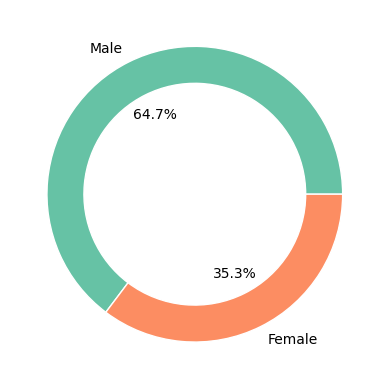

In [47]:
_sns_db = pd.melt(
    db_clinical, 
    id_vars=['patient_id', 'seqn'], 
    value_vars=db_clinical.copy().columns.drop(['patient_id', 'seqn'])
)

sex_map = {
    'Male': 1,
    'Female': 2
}

counts = _sns_db[_sns_db['variable'] == 'sex']['value'].dropna().map(sex_map).astype(int).value_counts()
plt.pie(
    counts,
    labels=counts.index.map(lambda x: 'Male' if x == 1 else 'Female'),
    colors=sns.color_palette('Set2'),
    autopct='%1.1f%%',
    wedgeprops={'width': 0.25, 'edgecolor': 'w'}
)
plt.show()

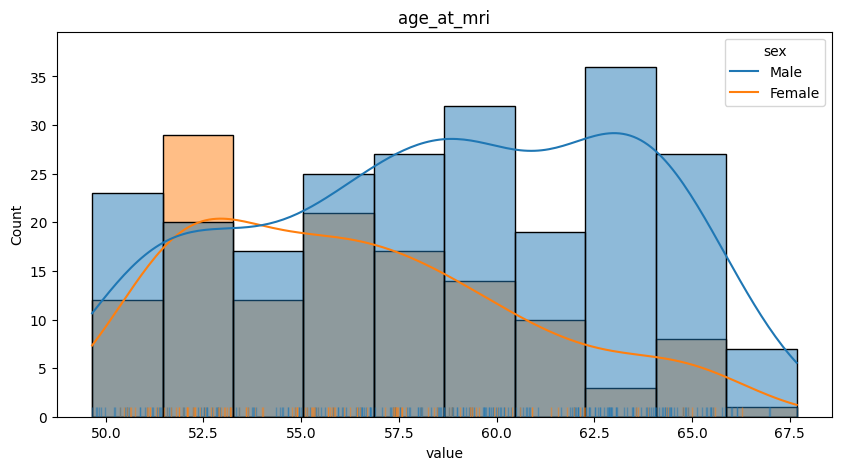

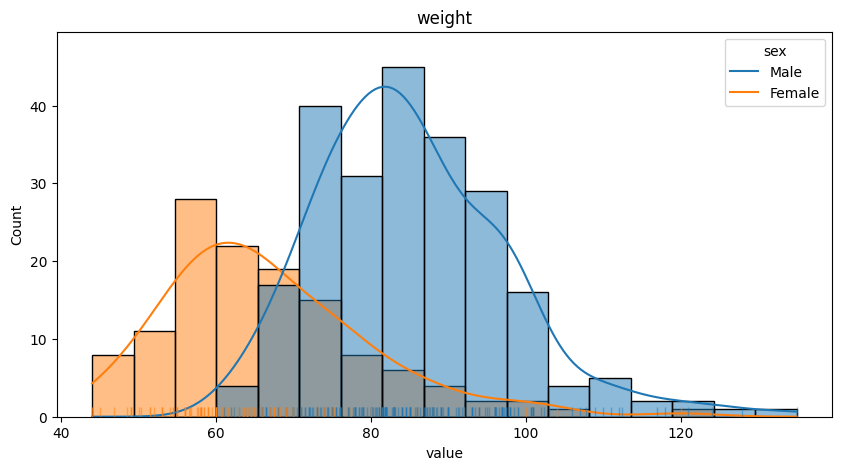

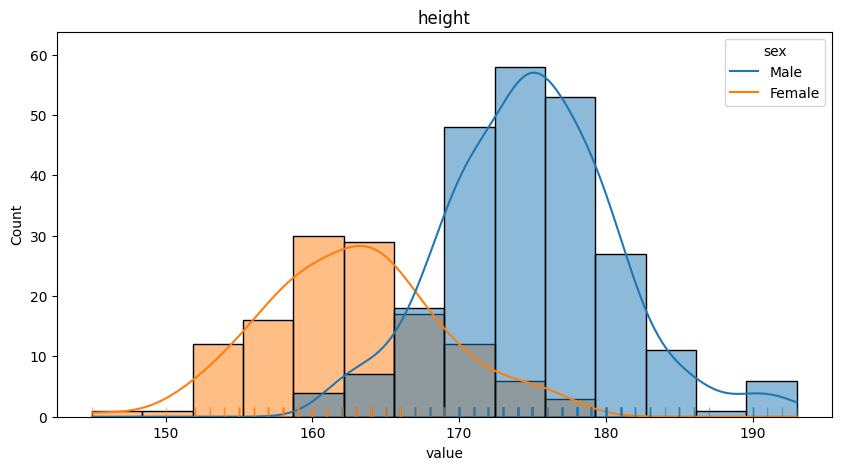

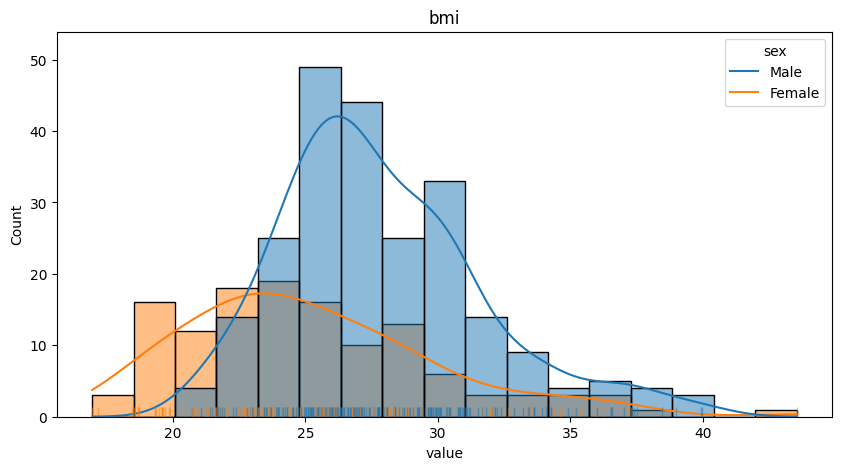

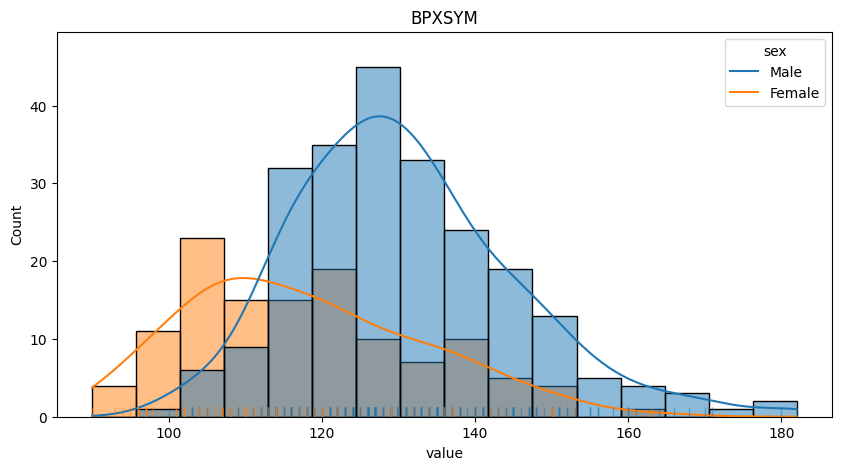

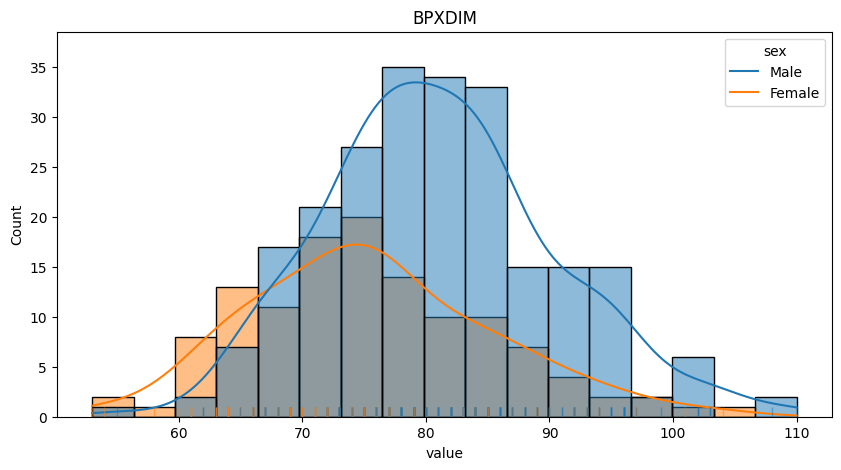

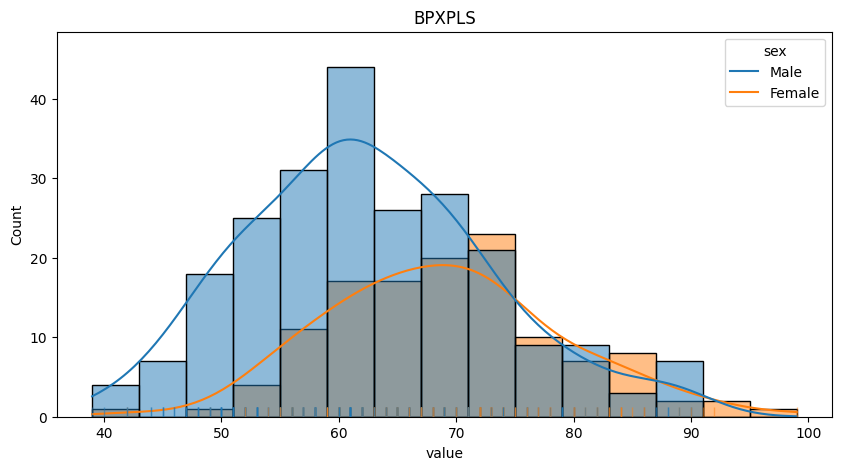

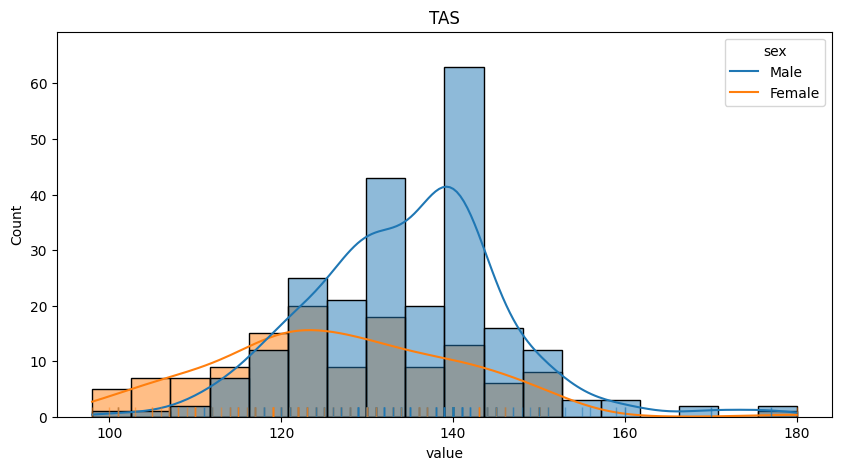

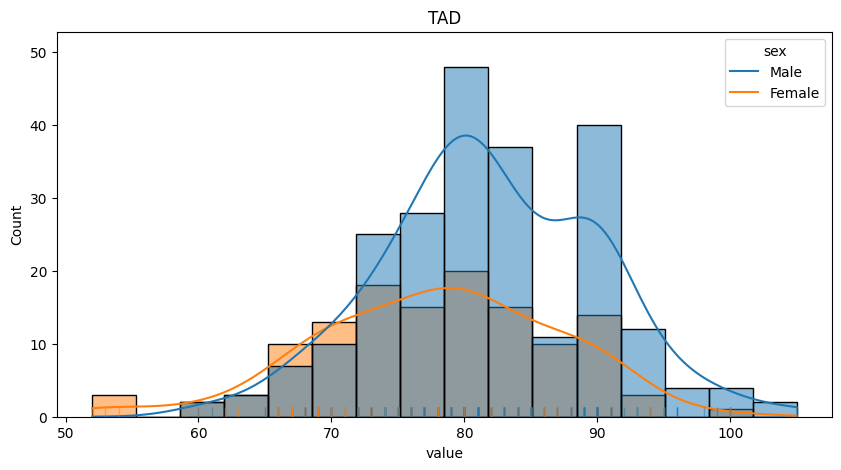

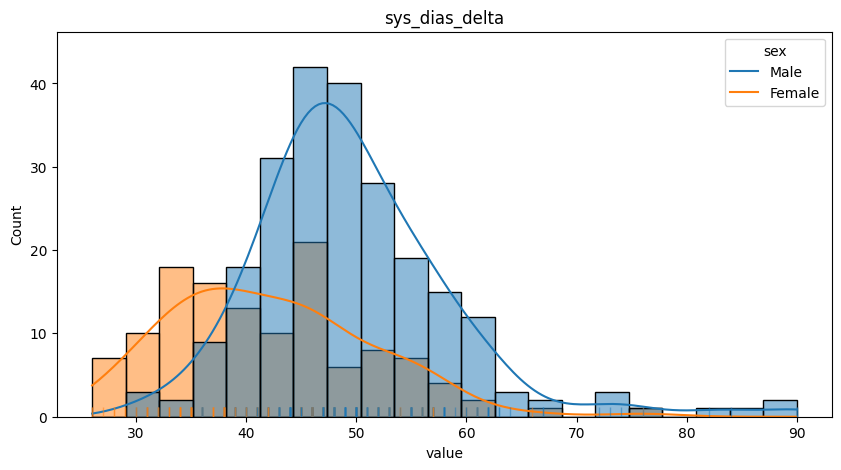

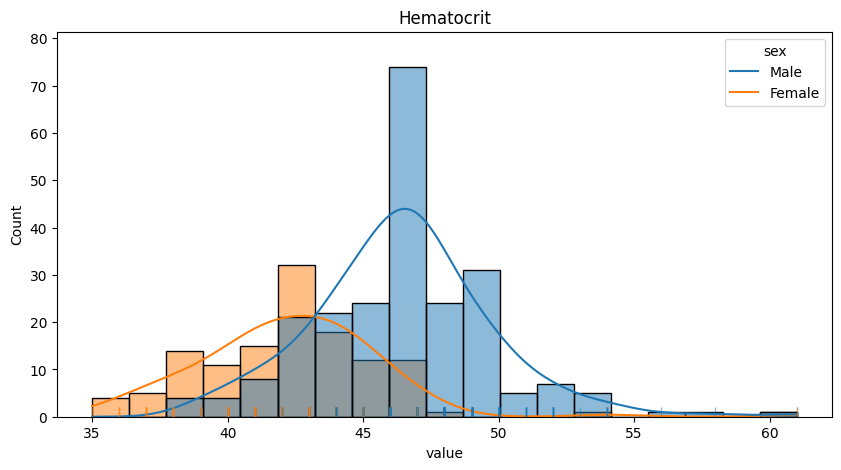

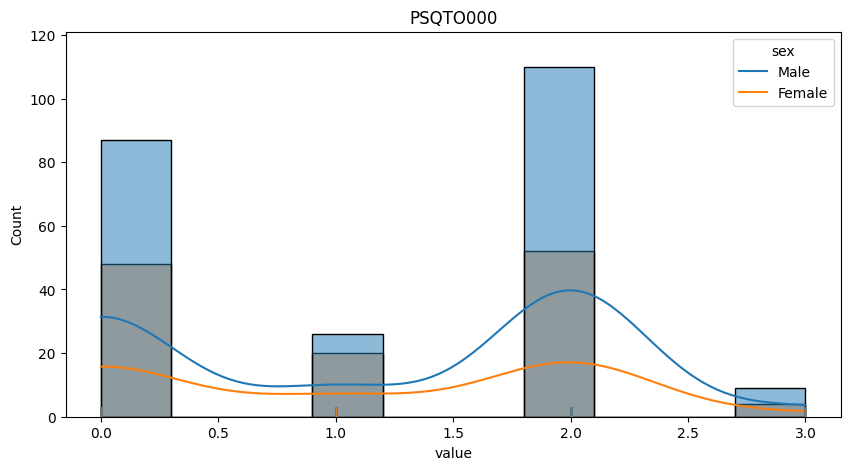

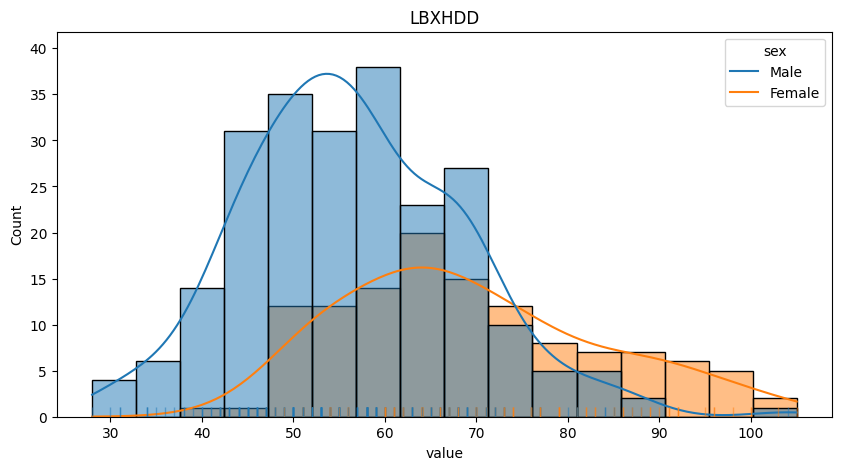

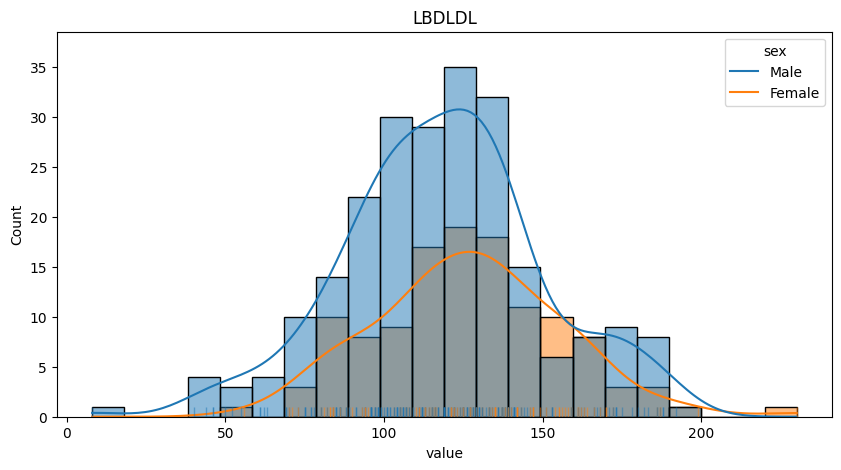

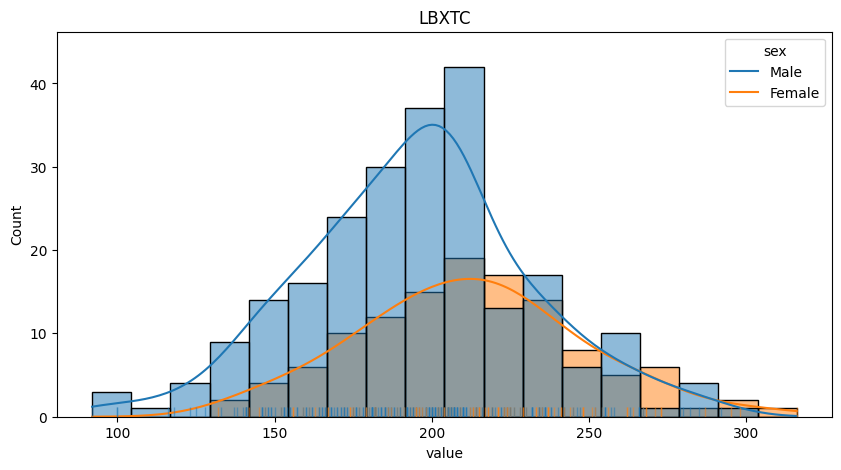

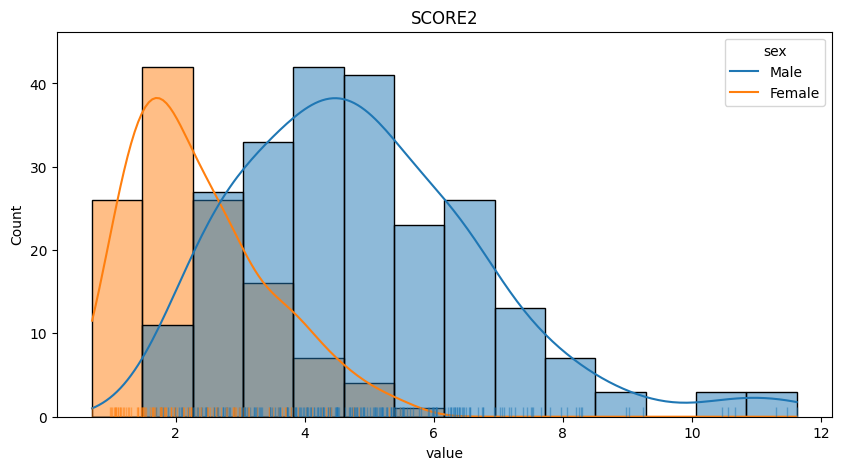

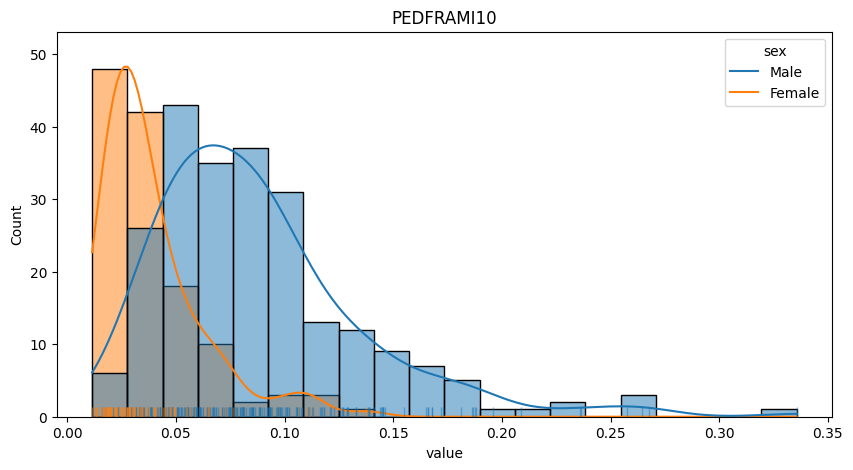

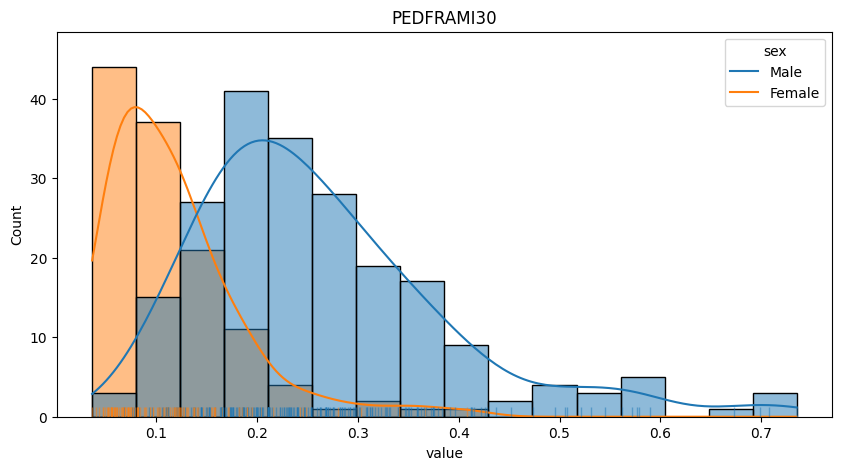

In [55]:
_features = db_clinical.copy().columns.drop(['patient_id', 'seqn', 'sex'])
# _features = ['age_at_mri']

for feat in _features:
    if feat not in ['age_at_mri']:
        _data = sns_db[sns_db['variable'] == feat].dropna()
    elif feat == 'LBDLDL':
        _data = sns_db[sns_db['variable'] == 'LBDLDL'].dropna()
    else:
        _data = sns_db[sns_db['variable'] == feat].dropna()

    try: _data['value'] = _data['value'].str.replace(',', '.').astype(float)
    except: pass
    plt.figure(figsize=(10, 5))
    plt.title(feat)
    # plt.subplot(1, 2, 1)
    sns.histplot(data=_data, x='value', hue='sex', kde=True)
    sns.rugplot(data=_data, x='value', alpha=0.5, hue='sex')

    # plt.subplot(1, 2, 2)
    # try:
    #     _skewness = skew(_data['value'].astype(float))
    #     probplot(_data['value'].astype(float), plot=plt)
    #     plt.title(f'Skewness: {_skewness}')
    # except:
    #     _skewness = skew(_data['value'].str.replace(',', '.').astype(float))
    #     probplot(_data['value'].str.replace(',', '.').astype(float), plot=plt)
    #     plt.title(f'Skewness: {_skewness}')
    plt.show()


In [56]:
_db_tac = db_tac[db_tac['patient_id'].isin(subjects_4dflow_available)]
_db_tac = _db_tac.merge(db_clinical, on='patient_id', how='left')
# _db_tac['tacsctot_group'] = _db_tac['tacsctot'].apply(lambda x: 'g0' if x == 0 else 'g1' if x <= 100 else 'g2' if x <= 400 else 'g3')
_db_tac = _db_tac[['patient_id', 'visit', 'tacsctot', 'tacsctot_group', 'sex']]
_db_tac 

,patient_id,visit,tacsctot,tacsctot_group,sex
0,PESA1521,4,87.50,g1,Male
1,PESA12996,4,0.00,g0,Female
2,PESA20164,4,33.97,g1,Male
3,PESA48841,4,0.00,g0,Female
4,PESA56169,4,0.00,g0,Male
...,...,...,...,...,...
351,PESA17505856,4,0.00,g0,Female
352,PESA17581249,4,9.60,g1,Female
353,PESA17867529,4,0.00,g0,Male
354,PESA17875984,4,0.00,g0,Female


In [57]:
sns_db = pd.melt(
    _db_tac, 
    id_vars=['patient_id', 'sex'], 
    value_vars=_db_tac.copy().columns.drop(['patient_id', 'sex'])
)

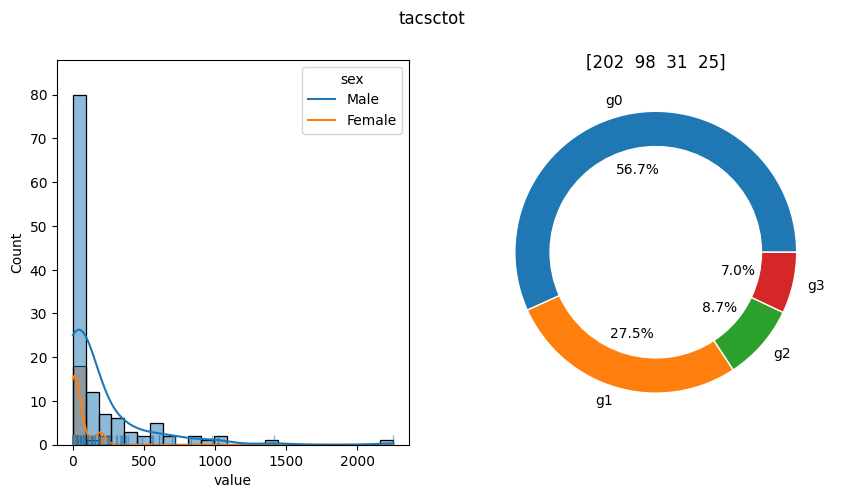

In [58]:
feat='tacsctot'
_data = sns_db[sns_db['variable'] == feat].dropna()
_data = _data[_data['value'] > 0]

plt.figure(figsize=(10, 5))
plt.suptitle(feat)
plt.subplot(1, 2, 1)
sns.histplot(data=_data, x='value', hue='sex', kde=True)
sns.rugplot(data=_data, x='value', alpha=0.5, hue='sex')

# plt.subplot(1, 3, 2)
# try:
#     _skewness = skew(_data['value'].astype(float))
#     probplot(_data['value'].astype(float), plot=plt)
#     plt.title(f'Skewness: {_skewness}')
# except:
#     _skewness = skew(_data['value'].str.replace(',', '.').astype(float))
#     probplot(_data['value'].str.replace(',', '.').astype(float), plot=plt)
#     plt.title(f'Skewness: {_skewness}')

plt.subplot(1, 2, 2)
_counts = sns_db[sns_db['variable'] == 'tacsctot_group']['value'].dropna().value_counts()
plt.pie(
    _counts,
    labels=_counts.index,
    autopct='%1.1f%%',
    wedgeprops={'width': 0.25, 'edgecolor': 'w'}
)
plt.title(f'{_counts.values}')

plt.show()

In [59]:
db_plaque = db_echo_carotide_plaque_vol[db_echo_carotide_plaque_vol['patient_id'].isin(subjects_4dflow_available)]
db_plaque = db_plaque.merge(db_clinical, on='patient_id', how='left')
db_plaque = db_plaque[['patient_id', 'sex', 'total_plaque_vol', 'left_carotid_plaque_vol', 'right_carotid_plaque_vol', 'total_femoral_plaque_vol', 'total_carotid_plaque_vol']]
db_plaque

,patient_id,sex,total_plaque_vol,left_carotid_plaque_vol,right_carotid_plaque_vol,total_femoral_plaque_vol,total_carotid_plaque_vol
0,PESA1521,Male,137.053728,0.000000,28.908432,108.145296,28.908432
1,PESA12996,Female,25.823952,0.000000,0.000000,25.823952,0.000000
2,PESA20164,Male,0.000000,0.000000,0.000000,0.000000,0.000000
3,PESA48841,Female,14.711256,0.000000,0.000000,14.711256,0.000000
4,PESA56169,Male,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...
363,PESA17505856,Female,0.000000,0.000000,0.000000,0.000000,0.000000
364,PESA17581249,Female,0.000000,0.000000,0.000000,0.000000,0.000000
365,PESA17867529,Male,48.220704,48.220704,0.000000,0.000000,48.220704
366,PESA17875984,Female,0.000000,0.000000,0.000000,0.000000,0.000000


In [60]:
sns_db = pd.melt(
    db_plaque, 
    id_vars=['patient_id', 'sex'], 
    value_vars=db_plaque.copy().columns.drop(['patient_id', 'sex'])
)

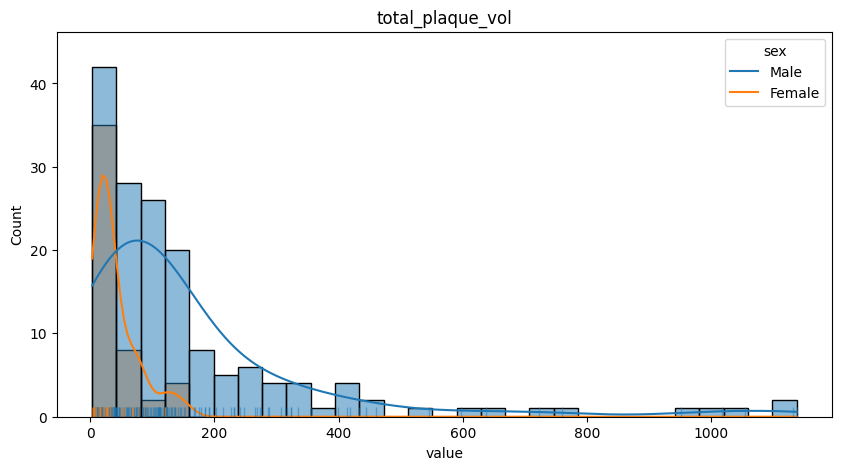

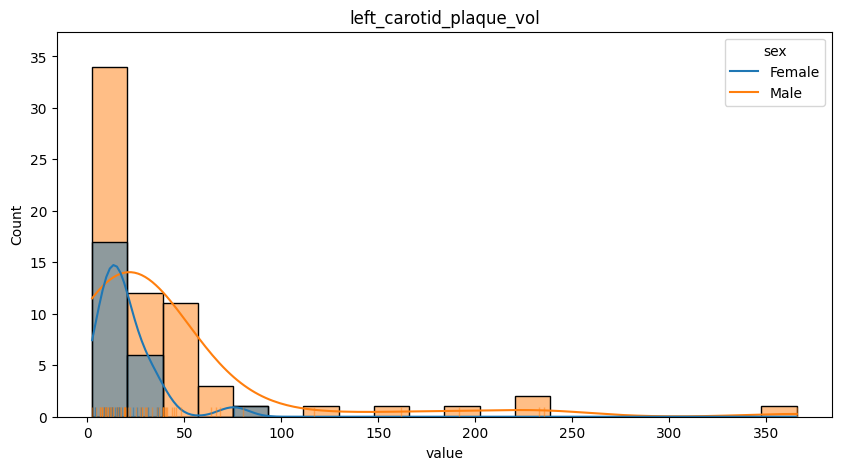

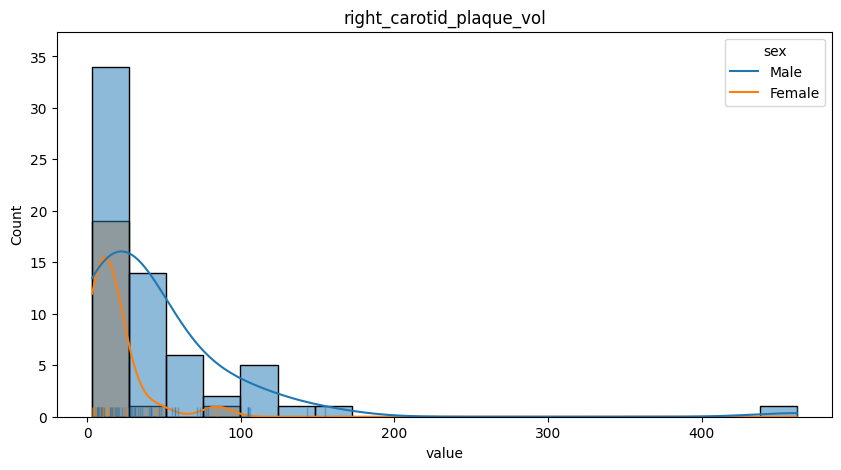

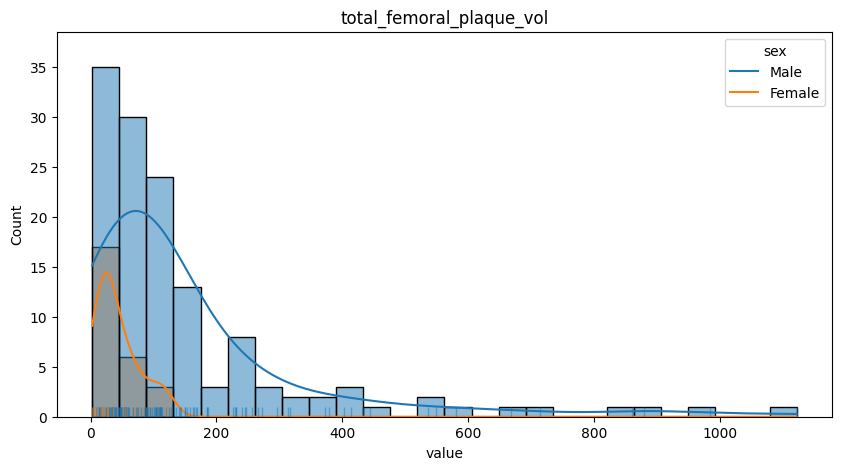

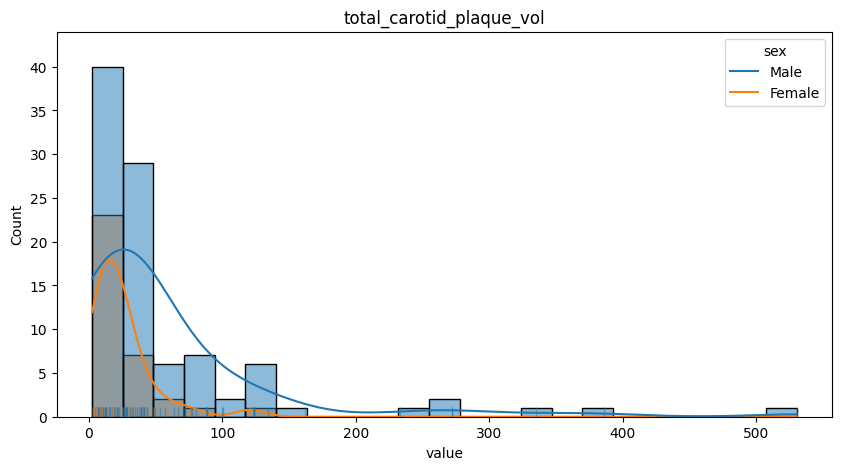

In [61]:
_features = db_plaque.copy().columns.drop(['patient_id', 'sex'])
# _features = ['age_at_mri']

for feat in _features:
    _data = sns_db[sns_db['variable'] == feat].dropna()
    _data = _data[_data['value'] > 0]

    plt.figure(figsize=(10, 5))
    plt.title(feat)
    # plt.subplot(1, 2, 1)
    sns.histplot(data=_data, x='value', hue='sex', kde=True)
    sns.rugplot(data=_data, x='value', alpha=0.5, hue='sex')

    # plt.subplot(1, 2, 2)
    # try:
    #     _skewness = skew(_data['value'].astype(float))
    #     probplot(_data['value'].astype(float), plot=plt)
    #     plt.title(f'Skewness: {_skewness}')
    # except:
        
    #     _skewness = skew(_data['value'].str.replace(',', '.').astype(float))
    #     probplot(_data['value'].str.replace(',', '.').astype(float), plot=plt)
    #     plt.title(f'Skewness: {_skewness}')
    plt.show()

In [62]:
_df_apoe = df_apoe[df_apoe['patient_id'].isin(subjects_4dflow_available)]
_df_apoe = _df_apoe.merge(db_clinical, on='patient_id', how='left')
_df_apoe = _df_apoe[['patient_id', 'sex', 'apoe']]
_df_apoe

,patient_id,sex,apoe
0,PESA553536,Female,E3/E4
1,PESA16589329,Female,E3/E3
2,PESA16016004,Male,E2/E3
3,PESA16008001,Male,E3/E4
4,PESA16924996,Male,E3/E3
...,...,...,...
361,PESA5424241,Female,E3/E3
362,PESA4494400,Male,E3/E3
363,PESA16064064,Male,E3/E3
364,PESA9241600,Female,E3/E3


In [63]:
sns_db = pd.melt(
    _df_apoe, 
    id_vars=['patient_id', 'sex'], 
    value_vars=_df_apoe.copy().columns.drop(['patient_id', 'sex'])
)

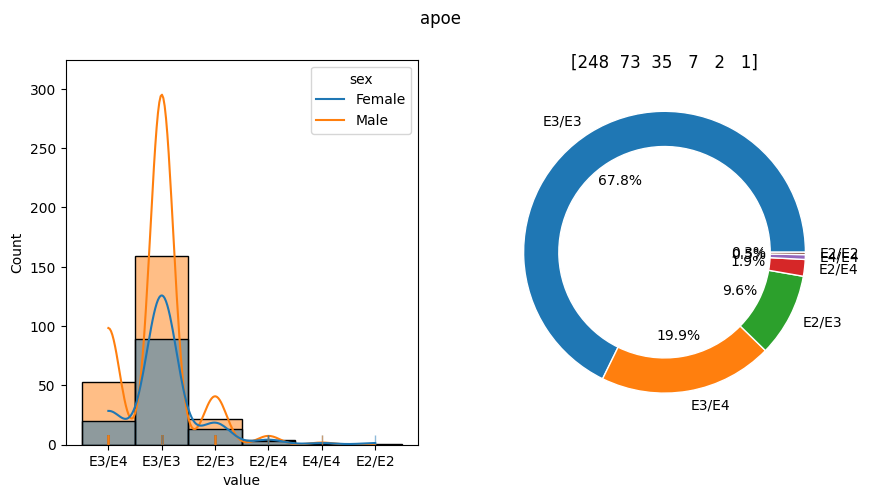

In [15]:
feat='apoe'
_data = sns_db[sns_db['variable'] == feat].dropna()

plt.figure(figsize=(10, 5))
plt.suptitle(feat)
plt.subplot(1, 2, 1)
sns.histplot(data=_data, x='value', hue='sex', kde=True)
sns.rugplot(data=_data, x='value', alpha=0.5, hue='sex')

plt.subplot(1, 2, 2)
_counts = sns_db[sns_db['variable'] == feat]['value'].dropna().value_counts()
plt.pie(
    _counts,
    labels=_counts.index,
    autopct='%1.1f%%',
    wedgeprops={'width': 0.25, 'edgecolor': 'w'}
)
plt.title(f'{_counts.values}')

plt.show()

REPORT

In [34]:
def generate_table_rows(df, variable_config):
    """
    df: Your pandas DataFrame
    variable_config: A list of dicts containing {'var': 'ColName', 'label': 'Display Name', 'unit': 'Units', 'desc': 'Description'}
    """
    html_rows = ""
    
    for item in variable_config:
        var_name = item['var']
        
        # Check if variable exists in dataframe
        if var_name not in df.columns:
            # Fallback for missing data
            stats = {k: "-" for k in ['n', 'mean', 'min_max', 'std', 'p5', 'p95']}
        else:
            col = pd.to_numeric(df[var_name], errors='coerce').dropna()
            
            if col.empty:
                stats = {k: "-" for k in ['n', 'mean', 'min_max', 'std', 'p5', 'p95']}
            else:
                stats = {
                    'n': len(col),
                    'mean': f"{col.mean():.2f}",
                    'min_max': f"{col.min():.1f}-{col.max():.1f}",
                    'std': f"{col.std():.2f}",
                    'p5': f"{col.quantile(0.05):.2f}",
                    'p95': f"{col.quantile(0.95):.2f}"
                }

        # Build the HTML row
        row = f"""
    <tr>
      <td style="padding: 8px; border-bottom: 1px solid #eee;"><b>{item['label']}</b></td>
      <td style="padding: 8px; border-bottom: 1px solid #eee; text-align: center;">{item['unit']}</td>
      <td style="padding: 8px; border-bottom: 1px solid #eee; text-align: center;">{stats['n']}</td>
      <td style="padding: 8px; border-bottom: 1px solid #eee; text-align: center;">{stats['mean']} +- {stats['std']}</td>
      <td style="padding: 8px; border-bottom: 1px solid #eee; text-align: center;">{stats['min_max']}</td>
      <td style="padding: 8px; border-bottom: 1px solid #eee; text-align: center;">{stats['p5']}</td>
      <td style="padding: 8px; border-bottom: 1px solid #eee; text-align: center;">{stats['p95']}</td>
      <td style="padding: 8px; border-bottom: 1px solid #eee; text-align: center;">{item['desc']}</td>
    </tr>"""
        html_rows += row
        
    return html_rows

variable_config = [
    # --- BASIC ---
    {'var': 'sex', 'label': 'Sex', 'unit': '-', 'desc': '(64.7% Male / 35.3% Female)'},
    {'var': 'age_at_mri', 'label': 'Age at MRI', 'unit': 'Years', 'desc': '(ImagingDate - BirthDate).days / 365'},
    {'var': 'weight', 'label': 'Weight', 'unit': 'Kg', 'desc': "Patient's Weight [kg]"},
    {'var': 'height', 'label': 'Height', 'unit': 'Cm', 'desc': 'Patient Height [cm]'},
    {'var': 'bmi', 'label': 'BMI', 'unit': 'Kg/m2', 'desc': 'Weight / (Height / 100)**2 [kg/m2]'},
    {'var': 'PSQTO000', 'label': 'PSQTO000', 'unit': '-', 'desc': 'Smoker status; 0: non; 1: active; 2: former; 3: social'},
    {'var': 'LBXHDD', 'label': 'LBXHDD', 'unit': 'mg/dL', 'desc': 'Cholesterol HDL'},
    {'var': 'LBDLDL', 'label': 'LBDLDL', 'unit': 'mg/dL', 'desc': 'Cholesterol LDL'},
    {'var': 'LBXTC', 'label': 'LBXTC', 'unit': 'mg/dL', 'desc': 'Total Cholesterol'},

    # --- CARDIAC ---
    {'var': 'BPXSYM', 'label': 'BPXSYM', 'unit': 'mmHg', 'desc': 'mean(Systolic pressure, 3 measurements)'},
    {'var': 'BPXDIM', 'label': 'BPXDIM', 'unit': 'mmHg', 'desc': 'mean(Diastolic pressure, 3 measurements)'},
    {'var': 'BPXPLS', 'label': 'BPXPLS', 'unit': 'bpm', 'desc': 'Pulse'},
    {'var': 'TAS', 'label': 'TAS', 'unit': 'mmHg', 'desc': 'Systolic pressure at Imaging (Unique Measure)'},
    {'var': 'TAD', 'label': 'TAD', 'unit': 'mmHg', 'desc': 'Diastolic pressure at Imaging (Unique Measure)'},
    {'var': 'sys_dias_delta', 'label': 'ΔSys/Dias', 'unit': 'mmHg', 'desc': 'BPXSYM - BPXDIM'},
    {'var': 'Hematocrit', 'label': 'Hematocrit', 'unit': '%', 'desc': 'Blood density; % Red cells in blood'},
    {'var': 'SCORE2', 'label': 'PEDSCORE2 [V4]', 'unit': '-', 'desc': 'SCORE2 Risk Factor: $1 - S_{10}(t) \exp(\sum \\beta_i(X_i - \\bar{X}_i))$'},
    {'var': 'PEDFRAMI10', 'label': 'PEDFRAMI10 [V3]', 'unit': '-', 'desc': 'Framingham Risk Factor (10year)'},
    {'var': 'PEDFRAMI30', 'label': 'PEDFRAMI30 [V3]', 'unit': '-', 'desc': 'Framingham Risk Factor (30year)'},

    # --- CALCIUM [V4] ---
    {'var': 'tacsctot', 'label': 'TACSCTOT', 'unit': 'Agatston Units', 'desc': 'Total Calcium Score'},

    # --- PLAQUE [V3] ---
    {'var': 'left_carotid_plaque_vol', 'label': 'Left Carotid Plaque Vol', 'unit': 'mm3', 'desc': 'Volume of plaque in Left Carotid'},
    {'var': 'right_carotid_plaque_vol', 'label': 'Right Carotid Plaque Vol', 'unit': 'mm3', 'desc': 'Volume of plaque in Right Carotid'},
    {'var': 'total_carotid_plaque_vol', 'label': 'Total Carotid Plaque Vol', 'unit': 'mm3', 'desc': 'Combined Left and Right Carotid Volume'},
    {'var': 'total_femoral_plaque_vol', 'label': 'Total Femoral Plaque Vol', 'unit': 'mm3', 'desc': 'Total volume in Femoral arteries'},
    {'var': 'total_plaque_vol', 'label': 'Total Plaque Vol', 'unit': 'mm3', 'desc': 'Cumulative Plaque Volume across all sites'},

    # --- GENETIC ---
    {'var': 'apoe', 'label': 'APOE', 'unit': 'Genotype', 'desc': 'Apolipoprotein E Genotype status'}
]

In [38]:
db_report = db_clinical.copy()
db_report = db_report.merge(db_tac, on='patient_id', how='left')
db_report = db_report.merge(db_echo_carotide_plaque_vol, on='patient_id', how='left')
db_report = db_report.merge(db_apoe, on='patient_id', how='left')
db_report = db_report[db_report['patient_id'].isin(subjects_4dflow_available)]
# Remove patient_id duplicates
db_report = db_report.drop_duplicates(subset=['patient_id'])
db_report

,seqn_x,patient_id,age_at_mri,sex,weight,height,bmi,BPXSYM,BPXDIM,BPXPLS,...,visit,tacsctot,tacsctot_group,total_plaque_vol,left_carotid_plaque_vol,right_carotid_plaque_vol,total_femoral_plaque_vol,total_carotid_plaque_vol,seqn_y,apoe
2,38,PESA1521,66.99,Male,103.0,177.0,32.876887,116.0,76.0,61.0,...,4.0,87.50,g1,137.053728,0.000000,28.908432,108.145296,28.908432,38.0,E3/E4
13,113,PESA12996,55.28,Female,66.0,160.0,25.781250,113.0,71.0,53.0,...,4.0,0.00,g0,25.823952,0.000000,0.000000,25.823952,0.000000,113.0,E2/E3
17,141,PESA20164,60.11,Male,72.0,175.0,23.510204,118.0,75.0,65.0,...,4.0,33.97,g1,0.000000,0.000000,0.000000,0.000000,0.000000,141.0,E3/E3
35,220,PESA48841,59.32,Female,65.0,161.0,25.076193,130.0,80.0,72.0,...,4.0,0.00,g0,14.711256,0.000000,0.000000,14.711256,0.000000,220.0,E3/E3
37,236,PESA56169,52.81,Male,117.0,177.0,37.345590,117.0,73.0,75.0,...,4.0,0.00,g0,0.000000,0.000000,0.000000,0.000000,0.000000,236.0,E3/E3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1160,4183,PESA17505856,59.07,Female,44.0,154.0,18.552876,119.0,77.0,72.0,...,4.0,0.00,g0,0.000000,0.000000,0.000000,0.000000,0.000000,4183.0,E3/E3
1163,4192,PESA17581249,56.44,Female,51.5,153.0,22.000085,114.0,79.0,91.0,...,4.0,9.60,g1,0.000000,0.000000,0.000000,0.000000,0.000000,4192.0,E2/E3
1171,4226,PESA17867529,49.75,Male,79.0,179.0,24.655910,119.0,73.0,44.0,...,4.0,0.00,g0,48.220704,48.220704,0.000000,0.000000,48.220704,4226.0,E3/E4
1172,4227,PESA17875984,55.68,Female,52.0,164.0,19.333730,104.0,77.0,80.0,...,4.0,0.00,g0,0.000000,0.000000,0.000000,0.000000,0.000000,4227.0,E3/E3


In [42]:
db_report.info()

<class 'pandas.core.frame.DataFrame'>
Index: 356 entries, 2 to 1173
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   seqn_x                    356 non-null    int64  
 1   patient_id                356 non-null    object 
 2   age_at_mri                356 non-null    float64
 3   sex                       356 non-null    object 
 4   weight                    356 non-null    float64
 5   height                    356 non-null    float64
 6   bmi                       356 non-null    float64
 7   BPXSYM                    352 non-null    float64
 8   BPXDIM                    352 non-null    float64
 9   BPXPLS                    352 non-null    float64
 10  TAS                       356 non-null    float64
 11  TAD                       356 non-null    float64
 12  sys_dias_delta            352 non-null    float64
 13  Hematocrit                354 non-null    float64
 14  PSQTO000      

In [39]:
html_output = generate_table_rows(db_report, variable_config)
print(html_output)


    <tr>
      <td style="padding: 8px; border-bottom: 1px solid #eee;"><b>Sex</b></td>
      <td style="padding: 8px; border-bottom: 1px solid #eee; text-align: center;">-</td>
      <td style="padding: 8px; border-bottom: 1px solid #eee; text-align: center;">-</td>
      <td style="padding: 8px; border-bottom: 1px solid #eee; text-align: center;">- +- -</td>
      <td style="padding: 8px; border-bottom: 1px solid #eee; text-align: center;">-</td>
      <td style="padding: 8px; border-bottom: 1px solid #eee; text-align: center;">-</td>
      <td style="padding: 8px; border-bottom: 1px solid #eee; text-align: center;">-</td>
      <td style="padding: 8px; border-bottom: 1px solid #eee; text-align: center;">(64.7% Male / 35.3% Female)</td>
    </tr>
    <tr>
      <td style="padding: 8px; border-bottom: 1px solid #eee;"><b>Age at MRI</b></td>
      <td style="padding: 8px; border-bottom: 1px solid #eee; text-align: center;">Years</td>
      <td style="padding: 8px; border-bottom: 1px s